# **PAGE RANK DAN VISUALISASI NYA**

## Import Libary

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


## Load Dataset

In [3]:
# Membaca dataset
file_path = "/content/web-Google_10k.txt"

# Abaikan baris komentar (yang diawali '#')
df = pd.read_csv(file_path, sep='\t', comment='#', names=['FromNodeId', 'ToNodeId'])

# Tampilkan baris
print("Contoh isi dataset:")
print(df)


Contoh isi dataset:
       FromNodeId  ToNodeId
0               0     11342
1               0    824020
2               0    867923
3               0    891835
4           11342         0
...           ...       ...
78318      495600    271199
78319      495600    407927
78320      495600    555924
78321      495600    628974
78322      495600    905532

[78323 rows x 2 columns]


## Graph Berarah

In [4]:
# Buat graph berarah dari dataframe
G = nx.from_pandas_edgelist(df, source='FromNodeId', target='ToNodeId', create_using=nx.DiGraph())

# Info dasar graph
print(f"Jumlah node: {G.number_of_nodes()}")
print(f"Jumlah edge: {G.number_of_edges()}")


Jumlah node: 10000
Jumlah edge: 78323


## Page Rank Tertinggi

In [5]:
# Menghitung PageRank dengan algoritma default (damping factor 0.85)
pagerank_scores = nx.pagerank(G, alpha=0.85)

# Ubah ke DataFrame biar mudah diurutkan
pagerank_df = pd.DataFrame(list(pagerank_scores.items()), columns=['Node', 'PageRank'])

# Urutkan dari terbesar ke terkecil
pagerank_df = pagerank_df.sort_values(by='PageRank', ascending=False)

# Tampilkan 5 node dengan PageRank tertinggi
print("5 Node dengan PageRank tertinggi:")
print(pagerank_df.head(5))


5 Node dengan PageRank tertinggi:
        Node  PageRank
994   486980  0.006515
3849  285814  0.004633
113   226374  0.003301
2847  163075  0.003288
5214  555924  0.002756


## Visualisasi Node Page Rank dari yang Tertinggi sampai 100 Node

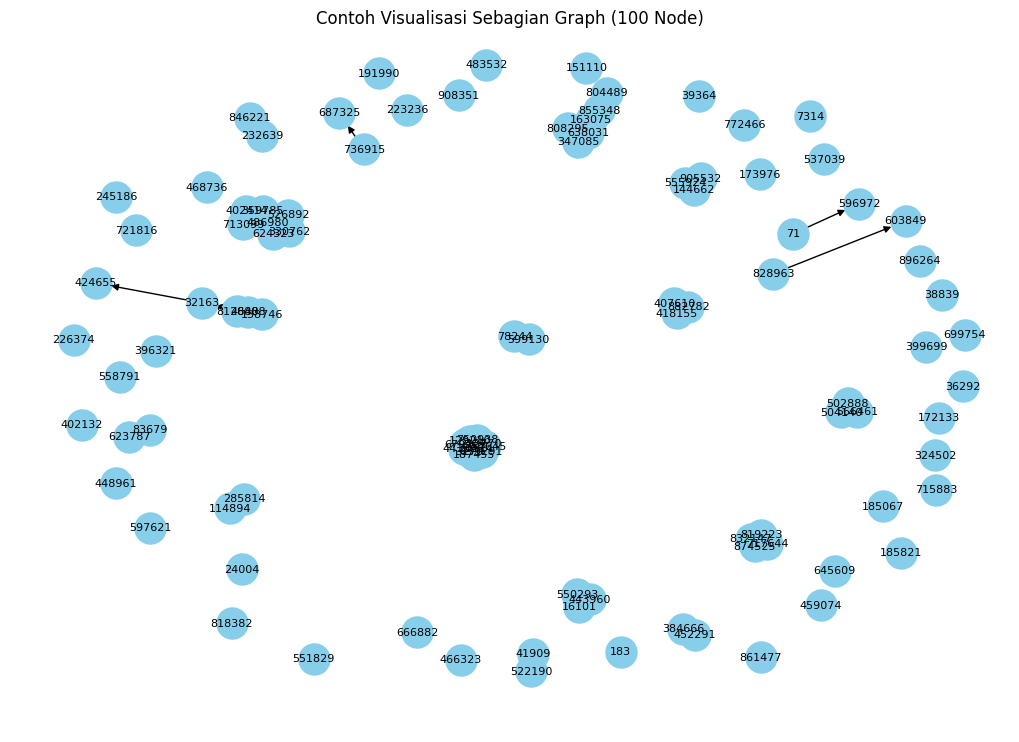

In [6]:
# Ambil 100 node ranking pertama untuk visualisasi
sample_nodes = list(pagerank_df['Node'][:100])
subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(10, 7))
nx.draw(subgraph, with_labels=True, node_size=500, node_color='skyblue', font_size=8, arrows=True)
plt.title("Contoh Visualisasi Sebagian Graph (100 Node)")
plt.show()


## Visualisai Node Page Rank dengan Rank Tertinggi dan Hubungannya

Node dengan PageRank tertinggi: 486980.0


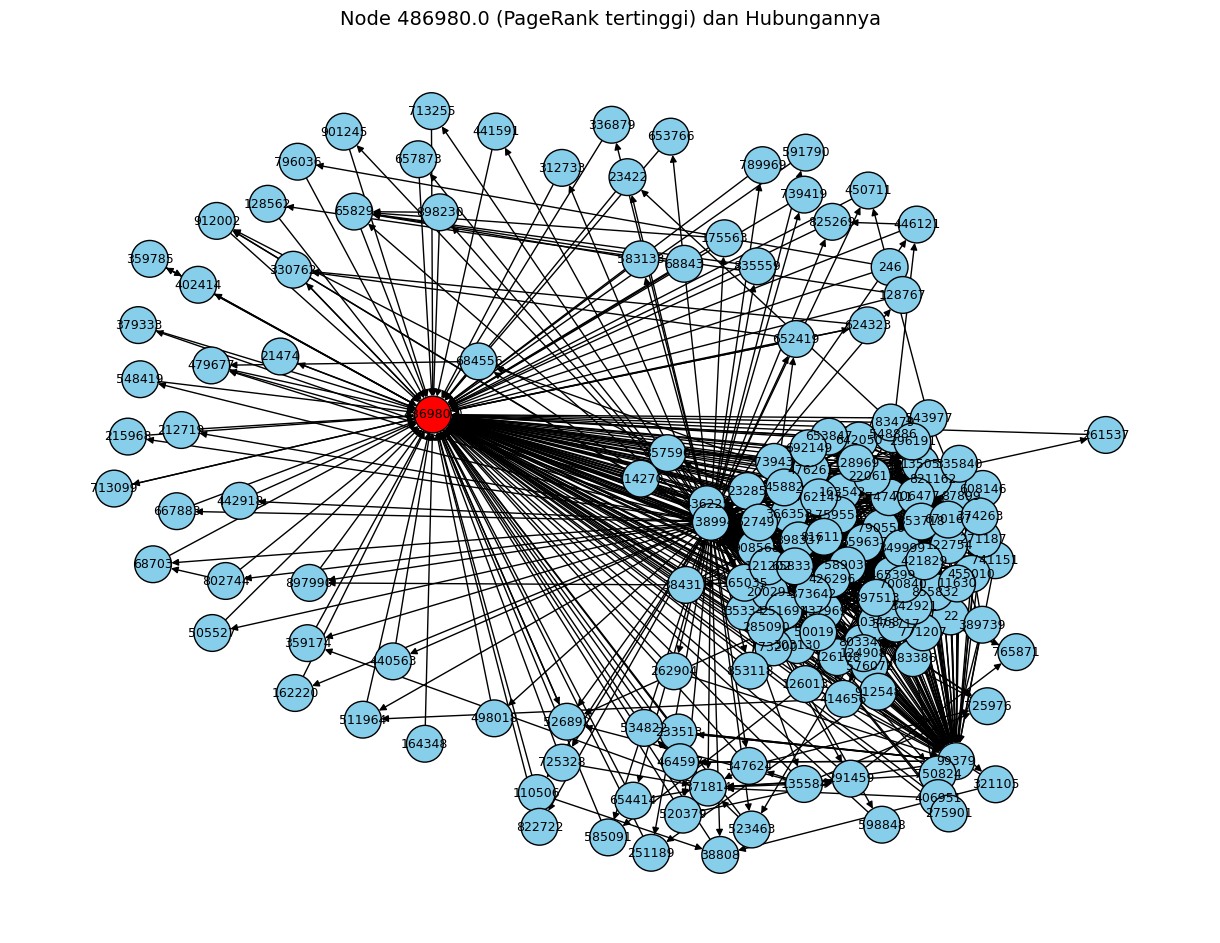

Jumlah node yang terhubung dengan 486980.0: 161
Daftar node yang terhubung:
[22, 13505, 87899, 99379, 124908, 465399, 658333, 738994, 233513, 464597, 534822, 23285, 73943, 103468, 121202, 126013, 126108, 163542, 165035, 200291, 251691, 271187, 285090, 303130, 342921, 366358, 374263, 384311, 389739, 414656, 426296, 436225, 437969, 455010, 476261, 483386, 526892, 543977, 548886, 575717, 608146, 653847, 659637, 692149, 700840, 706477, 741151, 747411, 762145, 803349, 816111, 821162, 855832, 857590, 897513, 908568, 912548, 330762, 359785, 402414, 624323, 713099, 11630, 21474, 23422, 35334, 38808, 45882, 65829, 68703, 110506, 114270, 122754, 128767, 128969, 135584, 162220, 175563, 212719, 215968, 220611, 251189, 261537, 262904, 275901, 291459, 296191, 312733, 321105, 335840, 336879, 347624, 349999, 353718, 359174, 371814, 373642, 379333, 406951, 421829, 440563, 441591, 442918, 446121, 450711, 479677, 498018, 500197, 505527, 511964, 520379, 523463, 548419, 576072, 583133, 585091, 589030, 5917

In [7]:
# Ambil 1 node dengan PageRank tertinggi
top_node = pagerank_df.iloc[0]['Node']
print(f"Node dengan PageRank tertinggi: {top_node}")

# Ambil semua node yang berhubungan (tetangga masuk dan keluar)
neighbors = list(G.predecessors(top_node)) + list(G.successors(top_node))

# Buat subgraph kecil berisi node tertinggi + tetangganya
focused_nodes = [top_node] + neighbors
subgraph_top = G.subgraph(focused_nodes)

# Gambar graph-nya
plt.figure(figsize=(12, 9))

# Warna node utama merah, tetangga biru
node_colors = ['red' if node == top_node else 'skyblue' for node in subgraph_top.nodes()]

# Gambar network
pos = nx.spring_layout(subgraph_top, seed=42)
nx.draw(
    subgraph_top,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=700,
    font_size=9,
    arrows=True,
    edgecolors='black'
)

plt.title(f"Node {top_node} (PageRank tertinggi) dan Hubungannya", fontsize=14)
plt.show()

# (Opsional) tampilkan daftar tetangga
print(f"Jumlah node yang terhubung dengan {top_node}: {len(neighbors)}")
print("Daftar node yang terhubung:")
print(neighbors)
